In [1]:
import uproot
import vector
import matplotlib.pyplot as plt
import tqdm
import numpy as np
import awkward as ak

In [2]:
sig = uproot.open("/vols/cms/us322/events_bbaa/02b_final_events_bbaa/signal_sm/batch_1/run_01_decayed_1/tag_1_pythia8_events_delphes.root")['Delphes']

sig.keys()

['Event',
 'Event/Event.fUniqueID',
 'Event/Event.fBits',
 'Event/Event.Number',
 'Event/Event.ReadTime',
 'Event/Event.ProcTime',
 'Event/Event.ProcessID',
 'Event/Event.MPI',
 'Event/Event.Weight',
 'Event/Event.CrossSection',
 'Event/Event.CrossSectionError',
 'Event/Event.Scale',
 'Event/Event.AlphaQED',
 'Event/Event.AlphaQCD',
 'Event/Event.ID1',
 'Event/Event.ID2',
 'Event/Event.X1',
 'Event/Event.X2',
 'Event/Event.ScalePDF',
 'Event/Event.PDF1',
 'Event/Event.PDF2',
 'Event_size',
 'Weight',
 'Weight/Weight.fUniqueID',
 'Weight/Weight.fBits',
 'Weight/Weight.Weight',
 'Weight_size',
 'Particle',
 'Particle/Particle.fUniqueID',
 'Particle/Particle.fBits',
 'Particle/Particle.PID',
 'Particle/Particle.Status',
 'Particle/Particle.IsPU',
 'Particle/Particle.M1',
 'Particle/Particle.M2',
 'Particle/Particle.D1',
 'Particle/Particle.D2',
 'Particle/Particle.Charge',
 'Particle/Particle.Mass',
 'Particle/Particle.E',
 'Particle/Particle.Px',
 'Particle/Particle.Py',
 'Particle/Parti

In [45]:
def compute_mass(pt1,pt2,eta1,eta2,phi1,phi2,mass1,mass2):
    j1 = vector.obj(pt=pt1, eta=eta1, phi=phi1, mass=mass1)
    j2 = vector.obj(pt=pt2, eta=eta2, phi=phi2, mass=mass2)

    candidate = j1+j2

    return candidate.mass, candidate.pt

In [46]:
# Select photons (PID==22), status 1, with Higgs (PID==25) mother via M1; remove from GenJets
pid = sig['Particle/Particle.PID'].array()
status = sig['Particle/Particle.Status'].array()
m1 = sig['Particle/Particle.M1'].array()

# Build masks
is_photon = pid == 22
is_status1 = status == 1

# Mother PID via index m1 (>=0), ensure within bounds
valid_m1 = m1 >= 0
mother_pid = ak.where(valid_m1, pid[m1], -9999)
from_higgs = mother_pid == 25

photon_mask = is_photon & is_status1 & from_higgs

In [47]:
# Get photons and sort by pT descending
p_pt = sig['Particle/Particle.PT'].array()
p_eta = sig['Particle/Particle.Eta'].array()
p_phi = sig['Particle/Particle.Phi'].array()

photons = ak.zip({
    'pt': p_pt,
    'eta': p_eta,
    'phi': p_phi,
    'pid': pid,
}, with_name='PhotonCand')

photons_sel = photons[photon_mask]
idx_sort = ak.argsort(photons_sel.pt, ascending=False)
photons_sorted = photons_sel[idx_sort]

# keep only two leading photons
leading_photons = photons_sorted[:, :2]

In [ ]:
# Now filter GenJets by removing entries that correspond to photons
jet_pt = sig['GenJet/GenJet.PT'].array()
jet_eta = sig['GenJet/GenJet.Eta'].array()
jet_phi = sig['GenJet/GenJet.Phi'].array()
jet_mass = sig['GenJet/GenJet.Mass'].array()
jet_flavor = sig['GenJet/GenJet.Flavor'].array()
jet_parts = sig['GenJet/GenJet.Constituents'].array()

# Many Delphes files set photon-like jets to Flavor==22; remove those
non_photon_jets_mask = (jet_flavor != 22)
orig_counts = ak.num(jet_pt, axis=1)

pt = jet_pt[non_photon_jets_mask]
eta = jet_eta[non_photon_jets_mask]
phi = jet_phi[non_photon_jets_mask]
mass = jet_mass[non_photon_jets_mask]
flavor = jet_flavor[non_photon_jets_mask]
parts = jet_parts[non_photon_jets_mask]

# Diagnostics: fraction of jets removed by Flavor filter (avg over events)
new_counts = ak.num(pt, axis=1)
removed_frac = (ak.sum(orig_counts - new_counts) / ak.sum(orig_counts))
print(f"Removed jets fraction by Flavor!=22 filter (avg over events): {removed_frac:.4f}")

# Sort jets by pT descending per event for consistent [0], [1] access
jet_order = ak.argsort(pt, ascending=False)
pt = pt[jet_order]
eta = eta[jet_order]
phi = phi[jet_order]
mass = mass[jet_order]

TypeError: no numpy.greater_equal overloads for custom types: TRefArray, int

This error occurred while calling

    numpy.greater_equal.__call__(
        <Array [[{fName: '', ...}, ...], ...] type='25000 * var * TRefArray...'>
        0
    )

In [ ]:
masses = []
for i in tqdm.tqdm(range(5000)):
    masses.append(compute_mass(pt[i,0],pt[i,1],eta[i,0],eta[i,1],phi[i,0],phi[i,1],mass[i,0],mass[i,1])[0])
    
masses = np.array(masses)
masses.shape

  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:19<00:00, 251.48it/s]


(5000,)

(array([  6.,   8.,   8.,  15.,  23.,  69., 198.,  26.,  32.,  44.,  67.,
         63.,  77.,  68.,  78.,  90., 100., 104., 105., 114., 126., 101.,
        121., 120.]),
 array([ 80. ,  87.5,  95. , 102.5, 110. , 117.5, 125. , 132.5, 140. ,
        147.5, 155. , 162.5, 170. , 177.5, 185. , 192.5, 200. , 207.5,
        215. , 222.5, 230. , 237.5, 245. , 252.5, 260. ]),
 [<matplotlib.patches.Polygon at 0x7f45dc7033a0>])

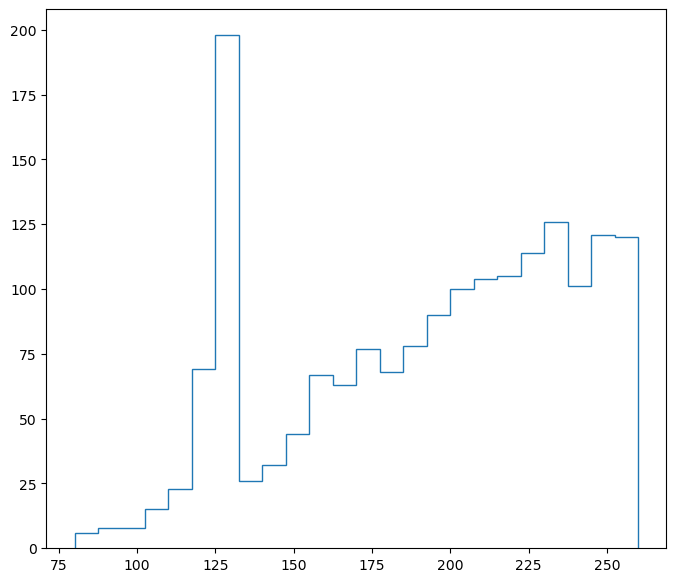

In [ ]:
fig,ax = plt.subplots(figsize=(8,7))
plt.hist(masses,bins=np.linspace(80,260,25),histtype='step',label='DiJet Mass')
#plt.show()